#**Modelo Predictivo de Depresión con Machine Learning**
##Universidad del Valle
##Escuela de Ingeniería de Sistemas y Computación
##Inteligencia artificial

## Oscar David Cuaical Lopez
## cuaical.oscar@correounivalle.edu.co

# **PARTE 1**
# 1. Importación de Librerías

## 1.1 Descripción general

En esta sección se importan las librerías necesarias para el desarrollo del proyecto. Estas herramientas permiten realizar:

- Manipulación y análisis de datos
- Visualización gráfica
- Preprocesamiento de datos
- Construcción y evaluación de modelos de aprendizaje automático

## 1.2 Librerías utilizadas

- `pandas`: manejo de estructuras de datos tipo DataFrame
- `numpy`: operaciones numéricas y arreglos
- `matplotlib`: generación de gráficos
- `scikit-learn`: herramientas para machine learning, incluyendo:
  - División de datos (`train_test_split`)
  - Escalamiento y codificación (`StandardScaler`, `OneHotEncoder`)
  - Transformaciones (`ColumnTransformer`)
  - Modelos (`MLPClassifier`)
  - Evaluación (`accuracy_score`, `confusion_matrix`, `log_loss`)
- `google.colab`: utilidades para manejo de archivos en el entorno Colab



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import log_loss

# 2. Carga de Datos y Preprocesamiento

## 2.1 Carga del conjunto de datos

En esta sección se monta el entorno de almacenamiento de Google Drive y se carga el conjunto de datos `depression.csv`. Este archivo contiene las variables predictoras y la variable objetivo relacionada con la depresión.

## 2.2 Definición de variables

El conjunto de datos se divide en:

- **Variables independientes (X):** contienen las características del dataset
- **Variable dependiente (y):** corresponde a la etiqueta `Depression`, que se desea predecir

## 2.3 División del conjunto de datos

Se realiza una partición del dataset en:

- **80% para entrenamiento**
- **20% para pruebas**

Se utiliza un valor fijo (`random_state=123`) para garantizar reproducibilidad en los resultados.

## 2.4 Identificación de tipos de variables

Se separan las variables en dos grupos:

- **Variables numéricas:** requieren normalización para mejorar el desempeño del modelo
- **Variables categóricas:** requieren codificación para ser utilizadas en modelos de machine learning

## 2.5 Transformación de datos

Se define un `ColumnTransformer` que permite aplicar:

- **Estandarización (`StandardScaler`)** a variables numéricas
- **Codificación One-Hot (`OneHotEncoder`)** a variables categóricas

Esto asegura que todas las variables estén en un formato adecuado para el entrenamiento del modelo.

In [4]:
# Montar Google Drive para acceder a los archivos almacenados
drive.mount('/content/drive')

# Cargar el dataset desde la ruta especificada en Google Drive
df = pd.read_csv("/content/drive/MyDrive/DATASET/depression.csv", header=0)

# Separar variables independientes (X) y variable objetivo (y)
X = df.drop('Depression', axis=1)
y = df['Depression']

# Dividir los datos en conjunto de entrenamiento (80%) y prueba (20%)
# Se fija random_state para asegurar reproducibilidad
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# Definir columnas numéricas que serán normalizadas
num_cols = ['Age', 'CGPA', 'Work/Study Hours']

# Definir columnas categóricas que serán codificadas
cat_cols = ['Gender', 'Sleep Duration', 'Degree',
            'Suicidal Thoughts', 'Family History of Mental Illness']

# Crear transformador de columnas:
# - StandardScaler para variables numéricas
# - OneHotEncoder para variables categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

# 3. Entrenamiento del Modelo 1 (Red Neuronal)

## 3.1 Descripción del modelo

En esta sección se construye un modelo de clasificación basado en una **red neuronal multicapa (MLPClassifier)**. Este tipo de modelo es capaz de capturar relaciones no lineales en los datos.

## 3.2 Estructura del pipeline

Se utiliza un `Pipeline` para integrar en un solo flujo:

1. **Preprocesamiento de datos**
   - Normalización de variables numéricas
   - Codificación de variables categóricas

2. **Modelo de clasificación**
   - Red neuronal con una capa oculta

Esta estructura garantiza que todas las transformaciones se apliquen de manera consistente durante el entrenamiento y la predicción.

## 3.3 Configuración del modelo

El modelo se define con los siguientes hiperparámetros:

- `hidden_layer_sizes=(50,)`: una capa oculta con 50 neuronas
- `activation='relu'`: función de activación ReLU
- `solver='adam'`: optimizador basado en gradiente adaptativo
- `max_iter=500`: número máximo de iteraciones
- `random_state=123`: semilla para reproducibilidad

## 3.4 Entrenamiento y evaluación

El modelo se entrena utilizando el conjunto de entrenamiento y posteriormente se evalúa sobre el conjunto de prueba utilizando la métrica de **accuracy**, que mide la proporción de predicciones correctas.

In [5]:
# Crear un pipeline que integra el preprocesamiento y el modelo de red neuronal
model1 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(50,),
        activation='relu',
        solver='adam',
        random_state=123,
        max_iter=500
    ))
])

# Entrenar el modelo con los datos de entrenamiento
model1.fit(X_train, y_train)

# Generar predicciones sobre el conjunto de prueba
y_pred1 = model1.predict(X_test)

# Calcular la métrica de accuracy
acc1 = accuracy_score(y_test, y_pred1)

# 4. Entrenamiento del Modelo 2 (Red Neuronal)

## 4.1 Descripción del modelo

En esta sección se construye un segundo modelo basado en una **red neuronal multicapa (MLPClassifier)**. A diferencia del modelo anterior, se incrementa la complejidad de la arquitectura para evaluar si esto mejora el desempeño.

## 4.2 Estructura del pipeline

Se mantiene el uso de un `Pipeline`, lo que permite integrar:

1. **Preprocesamiento de datos**
   - Escalamiento de variables numéricas
   - Codificación de variables categóricas

2. **Modelo de clasificación**
   - Red neuronal con múltiples capas ocultas

## 4.3 Configuración del modelo

El modelo presenta las siguientes características:

- `hidden_layer_sizes=(100, 50)`: dos capas ocultas con 100 y 50 neuronas respectivamente
- `activation='tanh'`: función de activación tangente hiperbólica
- `solver='adam'`: optimizador adaptativo
- `max_iter=500`: número máximo de iteraciones
- `random_state=123`: garantiza reproducibilidad

El aumento en el número de capas permite capturar relaciones más complejas en los datos.

## 4.4 Entrenamiento y evaluación

El modelo se entrena con el conjunto de entrenamiento y posteriormente se evalúa utilizando el conjunto de prueba mediante la métrica de **accuracy**, permitiendo comparar su desempeño frente al Modelo 1.

In [6]:
# Crear un pipeline con preprocesamiento y un modelo de red neuronal más complejo
model2 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='tanh',
        solver='adam',
        random_state=123,
        max_iter=500
    ))
])

# Entrenar el modelo con los datos de entrenamiento
model2.fit(X_train, y_train)

# Generar predicciones sobre el conjunto de prueba
y_pred2 = model2.predict(X_test)

# Calcular la métrica de accuracy
acc2 = accuracy_score(y_test, y_pred2)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# 5. Entrenamiento del Modelo 3 (Red Neuronal)

## 5.1 Descripción

Se implementa un tercer modelo basado en una red neuronal multicapa con mayor capacidad, con el objetivo de evaluar el impacto de una arquitectura más profunda en el desempeño.

## 5.2 Configuración

El modelo se define con:

- `hidden_layer_sizes=(100, 100)`: dos capas ocultas
- `activation='relu'`: función de activación
- `solver='sgd'`: optimización por descenso de gradiente
- `max_iter=500` y `random_state=123`

## 5.3 Evaluación

El modelo se entrena con los datos de entrenamiento y se evalúa en el conjunto de prueba mediante la métrica de **accuracy**, permitiendo su comparación con los modelos anteriores.

In [7]:
# Crear un pipeline con preprocesamiento y una red neuronal de mayor profundidad
model3 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(100, 100),
        activation='relu',
        solver='sgd',
        random_state=123,
        max_iter=500
    ))
])

# Entrenar el modelo
model3.fit(X_train, y_train)

# Generar predicciones
y_pred3 = model3.predict(X_test)

# Calcular accuracy
acc3 = accuracy_score(y_test, y_pred3)

# 6. Entrenamiento del Modelo 4 (Red Neuronal)

## 6.1 Descripción

Se construye un modelo con una arquitectura más profunda, incorporando tres capas ocultas para evaluar si un aumento en la complejidad mejora el desempeño.

## 6.2 Configuración

- `hidden_layer_sizes=(150, 100, 50)`: tres capas ocultas con 150, 100 y 50 neuronas
- `activation='tanh'`: funcion de activacion tangente hiperbolica
- `solver='adam'`
- `max_iter=500`, `random_state=123`

## 6.3 Evaluación

El modelo se entrena sobre el conjunto de entrenamiento y se evalúa en el conjunto de prueba mediante **accuracy**, permitiendo su comparación con los modelos anteriores.

In [8]:
# Crear un pipeline con una red neuronal de tres capas ocultas
model4 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(150, 100, 50),
        activation='tanh',
        solver='adam',
        random_state=123,
        max_iter=500
    ))
])

# Entrenar el modelo
model4.fit(X_train, y_train)

# Generar predicciones
y_pred4 = model4.predict(X_test)

# Calcular accuracy
acc4 = accuracy_score(y_test, y_pred4)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


# 7. Entrenamiento del Modelo 5 (Red Neuronal)

## 7.1 Descripción

Se implementa un modelo con una sola capa oculta de mayor tamaño, con el fin de evaluar el impacto de incrementar el número de neuronas en una arquitectura más simple.

## 7.2 Configuración

- `hidden_layer_sizes=(200,)`
- `activation='relu'`
- `solver='lbfgs'`
- `max_iter=500`, `random_state=123`

## 7.3 Evaluación

El modelo se entrena utilizando el conjunto de entrenamiento y se evalúa sobre el conjunto de prueba mediante la métrica de **accuracy**, permitiendo su comparación con los demás modelos propuestos.

In [9]:
# Crear un pipeline con una red neuronal de una capa oculta más amplia
model5 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(
        hidden_layer_sizes=(200,),
        activation='relu',
        solver='lbfgs',
        random_state=123,
        max_iter=500
    ))
])

# Entrenar el modelo
model5.fit(X_train, y_train)

# Generar predicciones
y_pred5 = model5.predict(X_test)

# Calcular accuracy
acc5 = accuracy_score(y_test, y_pred5)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


# 8. Evaluación mediante Matrices de Confusión

## 8.1 Descripción

En esta sección se construyen las matrices de confusión para cada uno de los modelos entrenados. Esta herramienta permite evaluar el desempeño de los modelos más allá del accuracy, mostrando:

- Predicciones correctas
- Errores de clasificación
- Distribución de aciertos por clase

## 8.2 Metodología

Se generan matrices de confusión para los cinco modelos utilizando el conjunto de prueba. Para facilitar la comparación:

- Todas las matrices se presentan en una sola figura
- Se organizan en una cuadrícula de 2 filas por 3 columnas
- Cada gráfico corresponde a un modelo específico

## 8.3 Interpretación

Las matrices permiten analizar:

- La cantidad de verdaderos positivos y negativos
- Los errores de clasificación (falsos positivos y falsos negativos)
- El comportamiento del modelo frente a cada clase

Este análisis complementa la métrica de accuracy y proporciona una visión más detallada del rendimiento de los modelos.

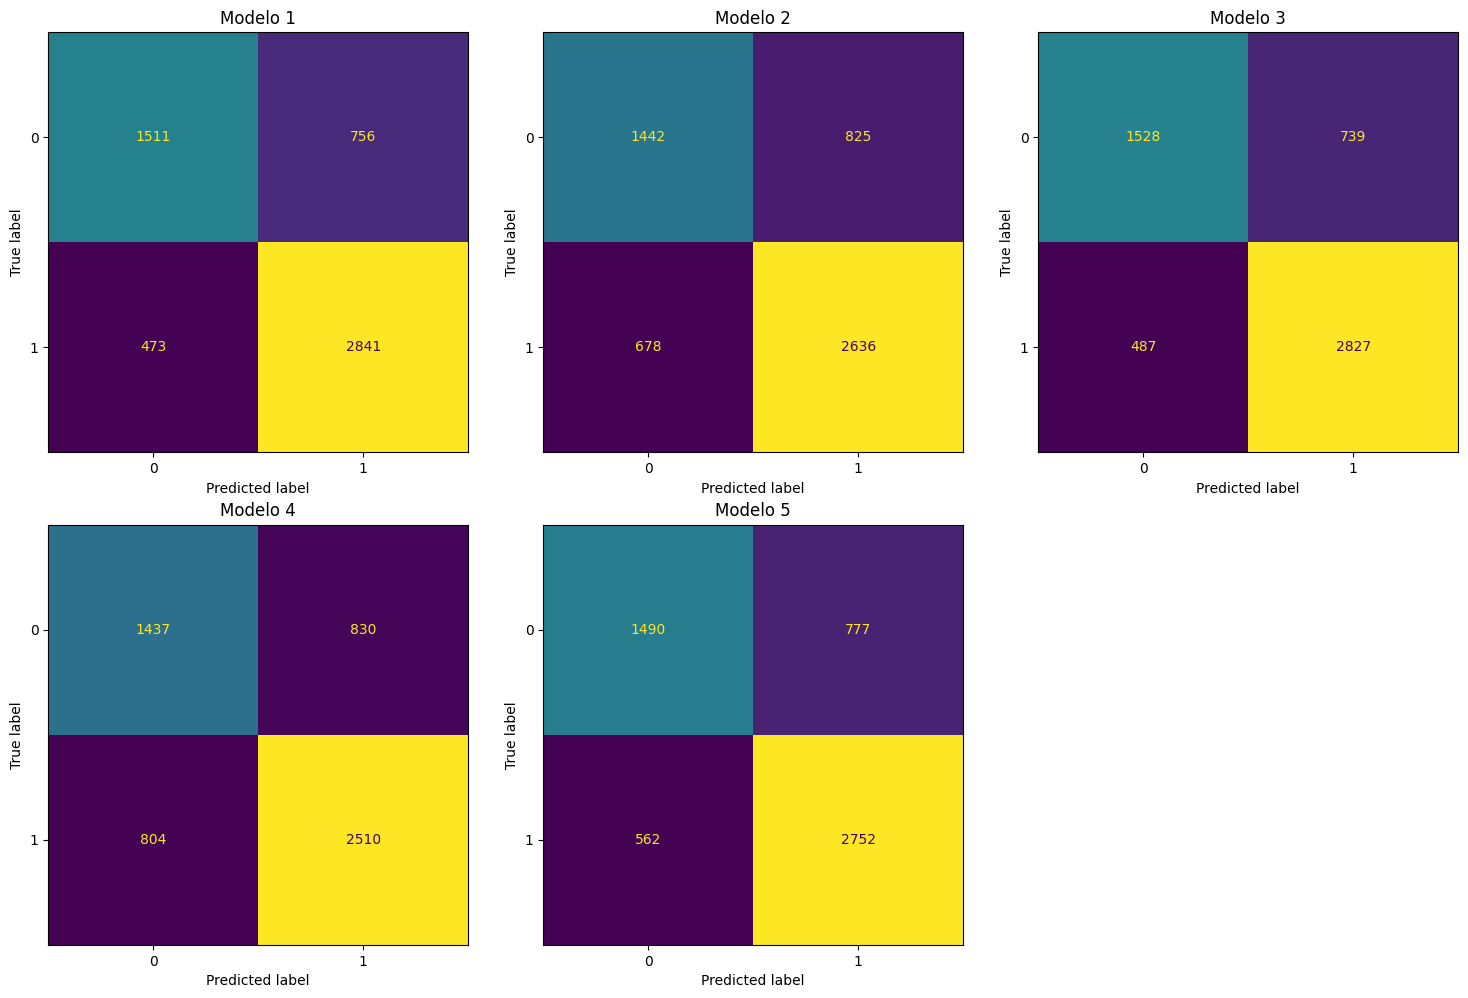

In [31]:
# Crear una figura con múltiples subgráficas (2 filas x 3 columnas)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Convertir la matriz de ejes en un arreglo unidimensional para facilitar la iteración
axes = axes.ravel()

# Lista de predicciones generadas por cada modelo
y_preds = [y_pred1, y_pred2, y_pred3, y_pred4, y_pred5]

# Títulos correspondientes a cada modelo
titles = [
    "Modelo 1",
    "Modelo 2",
    "Modelo 3",
    "Modelo 4",
    "Modelo 5"
]

# Generar y graficar la matriz de confusión para cada modelo
for i, (y_pred, title) in enumerate(zip(y_preds, titles)):

    # Calcular matriz de confusión
    cm = confusion_matrix(y_test, y_pred)

    # Crear visualización de la matriz
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)

    # Dibujar la matriz en el subplot correspondiente
    disp.plot(ax=axes[i], colorbar=False)

    # Asignar título al subplot
    axes[i].set_title(title)

# Eliminar el último subplot vacío (ya que hay 6 espacios y solo 5 modelos)
fig.delaxes(axes[5])

# Ajustar el espaciado entre gráficos
plt.tight_layout()

# Mostrar la figura completa
plt.show()

# 9. Comparación de Desempeño de los Modelos

## 9.1 Construcción de la tabla de resultados

En esta sección se consolidan los resultados obtenidos por cada uno de los modelos entrenados. La métrica utilizada para la comparación es el **accuracy**, calculado sobre el conjunto de prueba.

## 9.2 Objetivo

El objetivo de esta tabla es:

- Comparar el desempeño entre diferentes arquitecturas de red neuronal
- Identificar el modelo con mejor capacidad de generalización
- Facilitar el análisis global de los experimentos realizados

## 9.3 Interpretación

La tabla permite observar directamente qué modelo presenta el mejor rendimiento y cómo varía el desempeño en función de la arquitectura y los hiperparámetros utilizados.

In [15]:
results = pd.DataFrame({
    'Modelo': ['Modelo 1', 'Modelo 2', 'Modelo 3', 'Modelo 4', 'Modelo 5'],
    'Accuracy': [acc1, acc2, acc3, acc4, acc5]
})

results

,Modelo,Accuracy
0,Modelo 1,0.779789
1,Modelo 2,0.730693
2,Modelo 3,0.780326
3,Modelo 4,0.707221
4,Modelo 5,0.760079


# 10. Análisis de Regularización del Modelo

## 10.1 Objetivo

En esta sección se analiza el impacto del hiperparámetro **alpha**, el cual controla la regularización L2 en la red neuronal. Su objetivo es reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

## 10.2 Metodología

Se entrenan dos variaciones del modelo base modificando únicamente el valor de `alpha`:

- Variación 1: `alpha = 0.01`
- Variación 2: `alpha = 0.1`

El resto de los hiperparámetros se mantiene constante para asegurar una comparación justa.

## 10.3 Evaluación

Cada modelo se entrena con el conjunto de entrenamiento y se evalúa con el conjunto de prueba utilizando la métrica de **accuracy**.

In [12]:
# -------------------------
# Variación 1: alpha = 0.01
# -------------------------

model_alpha1 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100,50),
                          activation='tanh',
                          solver='adam',
                          alpha=0.01,
                          random_state=123,
                          max_iter=500))
])

model_alpha1.fit(X_train, y_train)
acc_alpha1 = accuracy_score(y_test, model_alpha1.predict(X_test))

# -------------------------
# Variación 2: alpha = 0.1
# -------------------------

model_alpha2 = Pipeline([
    ('prep', preprocessor),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100,50),
                          activation='tanh',
                          solver='adam',
                          alpha=0.1,
                          random_state=123,
                          max_iter=500))
])

model_alpha2.fit(X_train, y_train)
acc_alpha2 = accuracy_score(y_test, model_alpha2.predict(X_test))

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


In [13]:
best_acc = results['Accuracy'].max()

alpha_results = pd.DataFrame({
    'Configuración': ['Original', 'alpha=0.01', 'alpha=0.1'],
    'Accuracy': [best_acc, acc_alpha1, acc_alpha2]
})

alpha_results

,Configuración,Accuracy
0,Original,0.780326
1,alpha=0.01,0.752732
2,alpha=0.1,0.781939


# 11. Visualización Comparativa Final de Modelos

## 11.1 Objetivo

En esta sección se presentan los resultados finales del proyecto de forma gráfica, con el objetivo de comparar:

- El desempeño de los cinco modelos iniciales
- El impacto del ajuste del hiperparámetro alpha

## 11.2 Estructura de la visualización

Se construyen dos gráficas en una misma figura:

- **Gráfica 1:** Comparación del accuracy entre los cinco modelos evaluados
- **Gráfica 2:** Comparación del accuracy según diferentes valores del hiperparámetro alpha

## 11.3 Interpretación

Estas visualizaciones permiten identificar de forma clara:

- El modelo con mejor desempeño global
- El impacto de la complejidad del modelo
- La influencia de la regularización en el rendimiento final

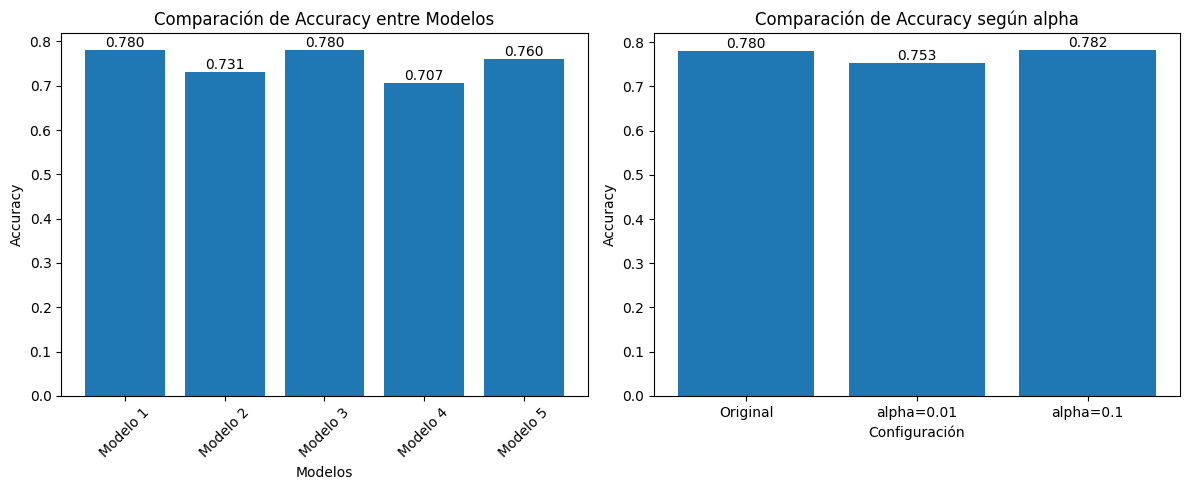

In [32]:
# -------------------------
# Datos de los modelos
# -------------------------

modelos = ["Modelo 1", "Modelo 2", "Modelo 3", "Modelo 4", "Modelo 5"]
accuracy_modelos = [0.779789, 0.730693, 0.780326, 0.707221, 0.760079]

configuraciones = ["Original", "alpha=0.01", "alpha=0.1"]
accuracy_config = [0.780326, 0.752732, 0.781939]

# Crear figura con dos subgráficas
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# -------------------------
# Gráfica 1: Modelos
# -------------------------

bars1 = axs[0].bar(modelos, accuracy_modelos)
axs[0].set_title("Comparación de Accuracy entre Modelos")
axs[0].set_xlabel("Modelos")
axs[0].set_ylabel("Accuracy")
axs[0].tick_params(axis='x', rotation=45)

# Agregar valores encima de cada barra
for bar in bars1:
    yval = bar.get_height()
    axs[0].text(
        bar.get_x() + bar.get_width() / 2,
        yval,
        f'{yval:.3f}',
        ha='center',
        va='bottom'
    )

# -------------------------
# Gráfica 2: Configuración alpha
# -------------------------

bars2 = axs[1].bar(configuraciones, accuracy_config)
axs[1].set_title("Comparación de Accuracy según alpha")
axs[1].set_xlabel("Configuración")
axs[1].set_ylabel("Accuracy")

# Agregar valores encima de cada barra
for bar in bars2:
    yval = bar.get_height()
    axs[1].text(
        bar.get_x() + bar.get_width() / 2,
        yval,
        f'{yval:.3f}',
        ha='center',
        va='bottom'
    )

# Ajustar distribución de la figura
plt.tight_layout()

# Mostrar gráfica final
plt.show()

# 12. Conclusión

Se evaluaron cinco modelos de clasificación, comparando su desempeño mediante la métrica de accuracy.

El mejor modelo base fue el **Modelo 3**, con un accuracy de **0.7803**, seguido muy de cerca por el Modelo 1.

Posteriormente, se realizó un ajuste de hiperparámetros sobre el Modelo 3, variando el valor de alpha.
Se encontró que la configuración **alpha = 0.1** obtuvo el mejor desempeño global, alcanzando un accuracy de **0.7819**, superando ligeramente al modelo original.

Sin embargo, las diferencias entre los modelos son pequeñas, por lo que sería recomendable complementar el análisis con otras métricas como precision, recall o F1-score, así como validación cruzada, para confirmar la robustez del modelo.

En conclusión, el mejor modelo es:
**Modelo 3 con alpha = 0.1**

# **PARTE 2**
# 1. Preparación de Datos para *Árboles de Decisión*

## 1.1 Carga del conjunto de datos

En esta sección se carga el dataset `depression.csv`, el cual será utilizado para entrenar modelos de árboles de decisión.

## 1.2 Definición de variables

Se separan los datos en:

- **Variables independientes (X):** contienen las características del conjunto de datos
- **Variable objetivo (y):** corresponde a la variable `Depression`

## 1.3 Identificación de tipos de datos

Se identifican las variables según su tipo:

- **Numéricas:** variables de tipo entero o flotante
- **Categóricas:** variables de tipo objeto

Esta separación permite aplicar transformaciones específicas a cada tipo de variable.

## 1.4 División del conjunto de datos

El dataset se divide en:

- **80% para entrenamiento**
- **20% para prueba**

Se utiliza `random_state=123` para asegurar la reproducibilidad.

## 1.5 Preprocesamiento

Se define un `ColumnTransformer` que aplica:

- **Estandarización (`StandardScaler`)** a variables numéricas
- **Codificación One-Hot (`OneHotEncoder`)** a variables categóricas

Finalmente, se ajusta el transformador con los datos de entrenamiento y se aplica al conjunto de prueba.

In [33]:
# Cargar el dataset desde Google Drive
df = pd.read_csv("/content/drive/MyDrive/DATASET/depression.csv", header=0)

# -------------------------
# Separación de variables
# -------------------------

# Variables independientes (características)
X = df.drop("Depression", axis=1)

# Variable objetivo
y = df["Depression"]

# -------------------------
# Identificación de columnas
# -------------------------

# Seleccionar columnas numéricas automáticamente
num_cols = X.select_dtypes(include=["int64", "float64"]).columns

# Seleccionar columnas categóricas automáticamente
cat_cols = X.select_dtypes(include=["object"]).columns

# -------------------------
# División de datos
# -------------------------

# Separar en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=123
)

# -------------------------
# Preprocesamiento
# -------------------------

# Definir transformaciones para cada tipo de variable
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
])

# Ajustar el preprocesador con los datos de entrenamiento
X_train_prep = preprocessor.fit_transform(X_train)

# Aplicar transformaciones al conjunto de prueba
X_test_prep = preprocessor.transform(X_test)

# 2. Entrenamiento de Árboles de Decisión (Criterio Gini)

## 2.1 Objetivo

En esta sección se entrenan múltiples modelos de árboles de decisión utilizando el criterio de división **Gini**, con el fin de analizar el impacto de la profundidad del árbol en el desempeño del modelo.

## 2.2 Configuración del modelo

Los modelos se configuran con los siguientes parámetros:

- `criterion = "gini"`
- `splitter = "best"`
- `random_state = 123`

Se varía el hiperparámetro:

- `max_depth`: desde 1 hasta 10

## 2.3 Metodología

Para cada valor de `max_depth`:

1. Se entrena un modelo de árbol de decisión
2. Se generan predicciones sobre el conjunto de prueba
3. Se calcula el accuracy
4. Se almacenan los resultados para su posterior análisis

## 2.4 Resultados

Los resultados se presentan en una tabla que relaciona la profundidad del árbol con el accuracy obtenido, lo que permite identificar el nivel óptimo de complejidad del modelo.

In [24]:
# Importar modelo de árbol de decisión y métrica de evaluación
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Lista para almacenar los resultados de accuracy
resultados_gini = []

# Evaluar modelos variando la profundidad del árbol (1 a 10)
for depth in range(1, 11):

    # Definir el modelo con criterio Gini
    model = DecisionTreeClassifier(
        criterion="gini",
        splitter="best",
        max_depth=depth,
        random_state=123
    )

    # Entrenar el modelo
    model.fit(X_train_prep, y_train)

    # Generar predicciones sobre el conjunto de prueba
    y_pred = model.predict(X_test_prep)

    # Calcular accuracy
    acc = accuracy_score(y_test, y_pred)

    # Guardar resultado
    resultados_gini.append(acc)

# Crear tabla de resultados
tabla_gini = pd.DataFrame({
    "max_depth": range(1, 11),
    "accuracy": resultados_gini
})

# Mostrar tabla
tabla_gini

,max_depth,accuracy
0,1,0.777818
1,2,0.777818
2,3,0.777818
3,4,0.781401
4,5,0.779609
5,6,0.782297
6,7,0.779072
7,8,0.778713
8,9,0.776743
9,10,0.768500


# 3. Entrenamiento de Árboles de Decisión (Criterio Entropy)

## 3.1 Objetivo

En esta sección se entrenan múltiples árboles de decisión utilizando el criterio de división **Entropy**, con el fin de comparar su desempeño frente al criterio Gini.

## 3.2 Configuración del modelo

Los modelos se definen con:

- `criterion = "entropy"`
- `splitter = "best"`
- `random_state = 123`

Se evalúa el hiperparámetro:

- `max_depth`: desde 1 hasta 10

## 3.3 Metodología

Para cada valor de profundidad:

1. Se entrena el modelo
2. Se generan predicciones sobre el conjunto de prueba
3. Se calcula el accuracy
4. Se almacenan los resultados

## 3.4 Resultados

Los resultados se presentan en una tabla que permite analizar cómo varía el desempeño del modelo en función de la profundidad del árbol.

In [25]:
# Lista para almacenar los resultados de accuracy con criterio Entropy
resultados_entropy = []

# Evaluar modelos variando la profundidad del árbol (1 a 10)
for depth in range(1, 11):

    # Definir el modelo con criterio Entropy
    model = DecisionTreeClassifier(
        criterion="entropy",
        splitter="best",
        max_depth=depth,
        random_state=123
    )

    # Entrenar el modelo
    model.fit(X_train_prep, y_train)

    # Generar predicciones
    y_pred = model.predict(X_test_prep)

    # Calcular accuracy
    acc = accuracy_score(y_test, y_pred)

    # Guardar resultado
    resultados_entropy.append(acc)

# Crear tabla de resultados
tabla_entropy = pd.DataFrame({
    "max_depth": range(1, 11),
    "accuracy": resultados_entropy
})

# Mostrar tabla
tabla_entropy

,max_depth,accuracy
0,1,0.777818
1,2,0.777818
2,3,0.777818
3,4,0.781401
4,5,0.779609
5,6,0.781580
6,7,0.778534
7,8,0.776026
8,9,0.772084
9,10,0.767604


Se construye una gráfica de líneas donde:

- El eje X representa la profundidad del árbol (`max_depth`)
- El eje Y representa el **accuracy** obtenido en el conjunto de prueba
- Se incluyen dos curvas:
  - Una para el criterio Gini
  - Otra para el criterio Entropy

### Interpretación

Esta visualización permite identificar:

- El punto donde el modelo alcanza su mejor desempeño
- Posibles casos de **subajuste** (baja profundidad)
- Posibles casos de **sobreajuste** (alta profundidad)

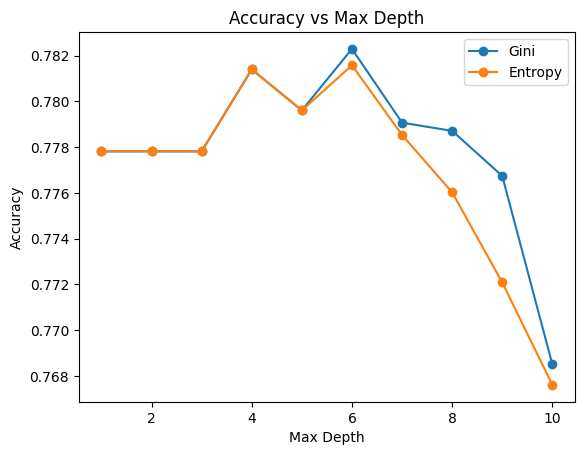

In [26]:
plt.figure()
plt.plot(range(1, 11), resultados_gini, marker='o', label="Gini")
plt.plot(range(1, 11), resultados_entropy, marker='o', label="Entropy")

plt.title("Accuracy vs Max Depth")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# 4. Selección del Mejor Modelo y Evaluación de Hiperparámetro Adicional

## 4.1 Identificación del mejor modelo

En esta sección se identifican los mejores modelos obtenidos previamente para cada criterio de división:

- **Gini**
- **Entropy**

La selección se realiza tomando el valor máximo de accuracy en cada tabla de resultados.

## 4.2 Comparación inicial

Se comparan ambos criterios para determinar cuál ofrece el mejor desempeño en el conjunto de prueba, considerando el valor óptimo de `max_depth`.

## 4.3 Evaluación de hiperparámetro adicional

Una vez identificado el mejor modelo base, se analiza el impacto de un hiperparámetro adicional:

- `min_samples_split`: número mínimo de muestras requeridas para dividir un nodo

Se evalúan diferentes valores de este parámetro manteniendo constantes los demás hiperparámetros.

## 4.4 Resultados

Los resultados se presentan en una tabla que permite observar si la modificación del hiperparámetro:

- Mejora el desempeño del modelo
- Lo mantiene estable
- O lo empeora

Este análisis permite comprender la sensibilidad del modelo a cambios en su configuración.

In [35]:
# -------------------------
# Identificación del mejor modelo
# -------------------------

# Obtener la fila con mayor accuracy para Gini
best_gini = tabla_gini.loc[tabla_gini["accuracy"].idxmax()]

# Obtener la fila con mayor accuracy para Entropy
best_entropy = tabla_entropy.loc[tabla_entropy["accuracy"].idxmax()]

# Mostrar resultados
print("Mejor Gini:\n", best_gini)
print("\nMejor Entropy:\n", best_entropy)


# -------------------------
# Evaluación de hiperparámetro adicional
# -------------------------

# Valores a probar para min_samples_split
valores = [2, 10, 20]

# Lista para almacenar resultados
resultados_extra = []

# Evaluar cada valor
for val in valores:

    # Definir modelo usando el mejor max_depth encontrado con Gini
    model = DecisionTreeClassifier(
        criterion="gini",                           # Mejor criterio identificado
        splitter="best",
        max_depth=int(best_gini["max_depth"]),      # Profundidad óptima
        min_samples_split=val,                      # Hiperparámetro adicional
        random_state=123
    )

    # Entrenar modelo
    model.fit(X_train_prep, y_train)

    # Generar predicciones
    y_pred = model.predict(X_test_prep)

    # Calcular accuracy
    acc = accuracy_score(y_test, y_pred)

    # Guardar resultado
    resultados_extra.append(acc)

# Crear tabla de resultados
tabla_extra = pd.DataFrame({
    "min_samples_split": valores,
    "accuracy": resultados_extra
})

# Mostrar tabla
tabla_extra

Mejor Gini:
 max_depth    6.000000
accuracy     0.782297
Name: 5, dtype: float64

Mejor Entropy:
 max_depth    6.00000
accuracy     0.78158
Name: 5, dtype: float64


,min_samples_split,accuracy
0,2,0.782297
1,10,0.782297
2,20,0.782297


# 5. Comparación Final de Modelos

## 5.1 Descripción

En esta sección se presenta una comparación gráfica de los mejores modelos obtenidos, considerando:

- El mejor árbol con criterio Gini
- El mejor árbol con criterio Entropy
- El modelo ajustado con el hiperparámetro `min_samples_split`

El objetivo es visualizar de forma clara cuál configuración ofrece el mejor desempeño en términos de accuracy.

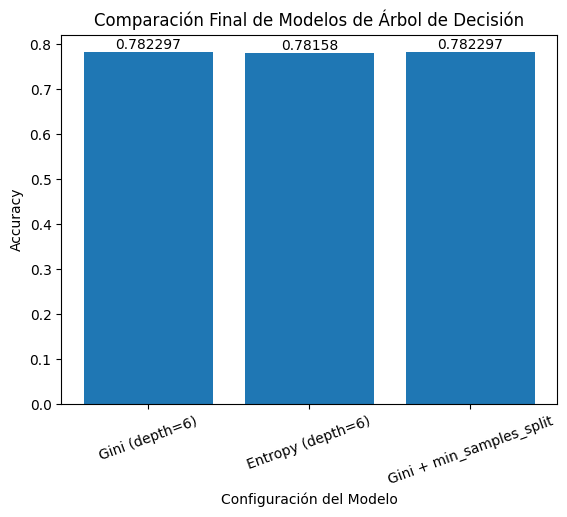

In [30]:
# Datos finales
modelos = [
    "Gini (depth=6)",
    "Entropy (depth=6)",
    "Gini + min_samples_split"
]

accuracies = [
    0.782297,
    0.781580,
    0.782297
]

plt.figure()
bars = plt.bar(modelos, accuracies)

# Valores encima
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 6),
             ha='center', va='bottom')

plt.title("Comparación Final de Modelos de Árbol de Decisión")
plt.ylabel("Accuracy")
plt.xlabel("Configuración del Modelo")
plt.xticks(rotation=20)

plt.show()

# 6. Conclusiones

Se evaluaron múltiples configuraciones de árboles de decisión variando el criterio de división y la profundidad del modelo.

Los resultados muestran que:

- El mejor desempeño se obtuvo con el criterio **Gini** y una profundidad de **6**, alcanzando un accuracy de **0.782297**
- El criterio **Entropy** presentó un comportamiento muy similar, aunque ligeramente inferior
- El modelo mejora a medida que aumenta la profundidad hasta cierto punto, pero luego disminuye su rendimiento, lo que evidencia un posible sobreajuste

Adicionalmente, al evaluar el hiperparámetro `min_samples_split`:

- No se observaron cambios en el accuracy al modificar su valor
- Esto indica que el modelo ya se encontraba en una configuración estable respecto a este parámetro

En conclusión, el modelo más adecuado corresponde a un árbol de decisión con:

- `criterion = "gini"`
- `max_depth = 6`

Estos resultados resaltan la importancia del ajuste de hiperparámetros para encontrar un equilibrio entre complejidad del modelo y capacidad de generalización.